In [1]:
from sqlalchemy.orm import sessionmaker
from PanoDB_link import engine,CommandLog
import pandas as pd
from datetime import datetime, timezone
import pytz

paris = pytz.timezone("Europe/Paris")

mois={
    1 :"janvier",
    2 :"février",
    3 :"mars",
    4 :"avril",
    5 :"mai",
    6 :"juin",
    7 :"juillet",
    8 :"août",
    9 :"septembre",
    10 :"octobre",
    11 :"novembre",
    12 :"décembre",   
}

import matplotlib.pyplot as plt


In [2]:
# Avec SQLAlchemy engine
logs = pd.read_sql("SELECT * FROM command_logs", con=engine)
logs['executed_at'] = logs['executed_at'].dt.tz_localize('UTC').dt.tz_convert('Europe/Paris')
logs.tail()


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
3820,3821,2025-09-23 03:27:01+02:00,6.609940e+17,chavkat.,1.224770e+18,Stellar - Dofus TOUCH,1.229493e+18,🏹stuffs,stuff,"{""classe"": ""pandawa"", ""element"": ""eau""}"
3821,3822,2025-09-23 11:28:55+02:00,1.036218e+18,fefe09188,1.303410e+18,✨ ＢＥＬＬＵＭ ✨,1.394447e+18,🫵│𝘛𝘰𝘯・𝘚𝘵𝘶𝘧𝘧,stuff,"{""element"": ""terre""}"
3822,3823,2025-09-23 12:31:08+02:00,2.666657e+17,lonlon4475,1.303410e+18,✨ ＢＥＬＬＵＭ ✨,1.394447e+18,🫵│𝘛𝘰𝘯・𝘚𝘵𝘶𝘧𝘧,stuff,"{""classe"": ""iop""}"
3823,3824,2025-09-23 13:19:11+02:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.344712e+18,💬│chat-metapano,stuff,{}
3824,3825,2025-09-23 13:19:23+02:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.344712e+18,💬│chat-metapano,stuff,"{""element"": ""terre""}"


In [3]:
logs_users=logs[logs["user_name"]!="warp_is_fine"]
logs_users

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
126,127,2025-02-06 09:51:00+01:00,8.476086e+17,blusterdofus,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""element"": ""air""}"
127,128,2025-02-06 18:49:51+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau""}"
128,129,2025-02-06 18:50:24+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau docrit""}"
132,133,2025-02-09 10:20:25+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air retrait""}"
133,134,2025-02-09 10:20:51+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""retrait pa""}"
...,...,...,...,...,...,...,...,...,...,...
3818,3819,2025-09-23 01:33:07+02:00,4.866521e+17,ogthem,1.213699e+18,[LIFE] Alliance,1.343900e+18,sram,stuff,"{""classe"": ""sram""}"
3819,3820,2025-09-23 01:36:22+02:00,4.866521e+17,ogthem,8.098754e+17,! 𝗞𝗚 Latif's server Privet,8.098754e+17,general,help,{}
3820,3821,2025-09-23 03:27:01+02:00,6.609940e+17,chavkat.,1.224770e+18,Stellar - Dofus TOUCH,1.229493e+18,🏹stuffs,stuff,"{""classe"": ""pandawa"", ""element"": ""eau""}"
3821,3822,2025-09-23 11:28:55+02:00,1.036218e+18,fefe09188,1.303410e+18,✨ ＢＥＬＬＵＭ ✨,1.394447e+18,🫵│𝘛𝘰𝘯・𝘚𝘵𝘶𝘧𝘧,stuff,"{""element"": ""terre""}"


In [4]:
nb_logs=len(logs)
nb_logs_guild_id_null=len(logs[logs["guild_id"].isna()])
nb_logs_guild_id_null_unique=len(logs[logs["guild_id"].isna()]["guild_name"].unique())
nb_guild_names=len(logs["guild_name"].unique())
nb_logs_channel_id_null=len(logs[logs["channel_id"].isna()])
nb_logs_channel_id_null_unique=len(logs[logs["channel_id"].isna()]["channel_name"].unique())
nb_channel_names=len(logs["channel_name"].unique())
nb_logs_user_id_null=len(logs[logs["user_id"].isna()])
nb_logs_user_id_null_unique=len(logs[logs["user_id"].isna()]["user_name"].unique())
nb_user_names=len(logs["user_name"].unique())

print(f"Nombre de logs : {nb_logs}")
print(f"Nombre de guilds : {nb_guild_names}")
print(f"Nombre de channels : {nb_channel_names}")
print(f"Nombre de users : {nb_user_names}")
print(f"Nombre de logs avec guild_id NULL : {nb_logs_guild_id_null} pour {nb_logs_guild_id_null_unique} uniques guild_name")
print(f"Nombre de logs avec channel_id NULL : {nb_logs_channel_id_null} pour {nb_logs_channel_id_null_unique} uniques channel_name")
print(f"Nombre de logs avec user_id NULL : {nb_logs_user_id_null} pour {nb_logs_user_id_null_unique} uniques user_name")


Nombre de logs : 3825
Nombre de guilds : 79
Nombre de channels : 121
Nombre de users : 444
Nombre de logs avec guild_id NULL : 193 pour 17 uniques guild_name
Nombre de logs avec channel_id NULL : 359 pour 39 uniques channel_name
Nombre de logs avec user_id NULL : 315 pour 104 uniques user_name


In [ ]:
logs[logs["executed_at"] > paris.localize(datetime(2025, 9, 22, 0, 0, 1))].sort_values(by="executed_at")

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
3784,3785,2025-09-22 01:48:58+02:00,2.919459e+17,cedp,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""feu eau""}"
3785,3786,2025-09-22 08:10:18+02:00,3.271735e+17,bjam1.,1.301967e+18,Horizon,1.396101e+18,🥋┃banque-de-stuff,stuff,{}
3786,3787,2025-09-22 08:10:50+02:00,3.271735e+17,bjam1.,1.301967e+18,Horizon,1.396101e+18,🥋┃banque-de-stuff,stuff,"{""classe"": ""eniripsa"", ""element"": ""feu eau soin""}"
3787,3788,2025-09-22 08:31:23+02:00,2.380323e+17,muuda,1.375955e+18,L'EMPIRE,1.396161e+18,🏦-banque-de-stuff,stuff,"{""classe"": ""roublard""}"
3788,3789,2025-09-22 13:37:13+02:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""classe"": ""iop""}"
3789,3790,2025-09-22 15:24:50+02:00,1.194424e+18,axyl0915,1.301967e+18,Horizon,1.396101e+18,🥋┃banque-de-stuff,help,{}
3790,3791,2025-09-22 15:25:02+02:00,1.194424e+18,axyl0915,1.301967e+18,Horizon,1.396101e+18,🥋┃banque-de-stuff,stuff,{}
3791,3792,2025-09-22 15:59:17+02:00,9.153452e+17,dkt_iv,5.228580e+17,Katoa,1.062693e+18,stuff-dofusbook🥋,stuff,"{""element"": ""air""}"
3792,3793,2025-09-22 16:00:30+02:00,9.153452e+17,dkt_iv,5.228580e+17,Katoa,1.062693e+18,stuff-dofusbook🥋,stuff,"{""element"": ""air dopou""}"
3793,3794,2025-09-22 17:09:34+02:00,6.057194e+17,zentoo,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""classe"": ""sram"", ""element"": ""air""}"


In [ ]:
commandes_par_mois=[]
for mois in range(1,10):
    commandes_par_mois.append(len(logs[logs["executed_at"] > paris.localize(datetime(2025, mois, 1, 0, 0, 1))][logs["executed_at"] < paris.localize(datetime(2025, mois+1, 1, 0, 0, 1))]))
commandes_par_mois

C:\Users\Joannes\AppData\Local\Temp\ipykernel_25508\457324781.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  commandes_par_mois.append(len(logs[logs["executed_at"] > paris.localize(datetime(2025, mois, 1, 0, 0, 1))][logs["executed_at"] < paris.localize(datetime(2025, mois+1, 1, 0, 0, 1))]))
C:\Users\Joannes\AppData\Local\Temp\ipykernel_25508\457324781.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  commandes_par_mois.append(len(logs[logs["executed_at"] > paris.localize(datetime(2025, mois, 1, 0, 0, 1))][logs["executed_at"] < paris.localize(datetime(2025, mois+1, 1, 0, 0, 1))]))
C:\Users\Joannes\AppData\Local\Temp\ipykernel_25508\457324781.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  commandes_par_mois.append(len(logs[logs["executed_at"] > paris.localize(datetime(2025, mois, 1, 0, 0, 1))][logs["executed_at"] < paris.localize(datetime(2025, mois+1, 1, 0, 0, 1))]))
C:\Users\Joan

[0, 222, 611, 228, 505, 274, 756, 703, 520]

In [ ]:
commandes_par_mois_users=[]
for mois in range(2,12):
    commandes_par_mois_users.append(len(logs_users[logs_users["executed_at"] > paris.localize(datetime(2025, mois, 1, 0, 0, 1))][logs_users["executed_at"] < paris.localize(datetime(2025, mois+1, 1, 0, 0, 1))]))
commandes_par_mois_users

C:\Users\Joannes\AppData\Local\Temp\ipykernel_25508\964406832.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  commandes_par_mois_users.append(len(logs_users[logs_users["executed_at"] > paris.localize(datetime(2025, mois, 1, 0, 0, 1))][logs_users["executed_at"] < paris.localize(datetime(2025, mois+1, 1, 0, 0, 1))]))
C:\Users\Joannes\AppData\Local\Temp\ipykernel_25508\964406832.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  commandes_par_mois_users.append(len(logs_users[logs_users["executed_at"] > paris.localize(datetime(2025, mois, 1, 0, 0, 1))][logs_users["executed_at"] < paris.localize(datetime(2025, mois+1, 1, 0, 0, 1))]))
C:\Users\Joannes\AppData\Local\Temp\ipykernel_25508\964406832.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  commandes_par_mois_users.append(len(logs_users[logs_users["executed_at"] > paris.localize(datetime(2025, mois, 1, 0, 0, 1))][logs_users["executed_at

[50, 147, 201, 324, 218, 591, 610, 468, 0, 0]

In [ ]:
[mois[i] for i in range(2,12)]

['février',
 'mars',
 'avril',
 'mai',
 'juin',
 'juillet',
 'août',
 'septembre',
 'octobre',
 'novembre']

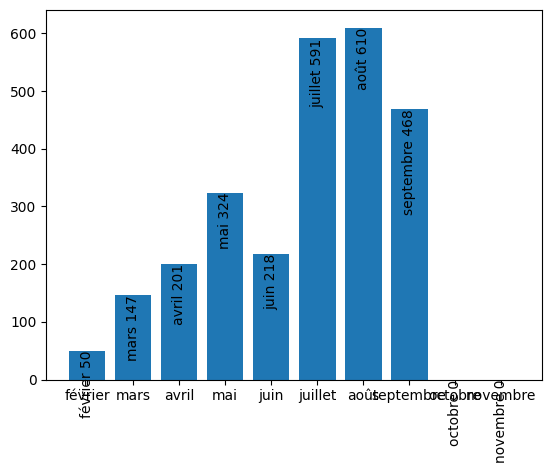

In [ ]:
fig, ax = plt.subplots()

ax.bar([mois[i] for i in range(2,12)],commandes_par_mois_users,)
# plt.xticks(rotation=45,ha="right")

for i in range(2,12):
    ax.text( i-2,commandes_par_mois_users[i-2], mois[i]+f" {commandes_par_mois_users[i-2]}", rotation=90,ha='center',va="top",color='black')


In [9]:
logs_users.loc[logs_users["guild_id"]==933448236939743360.0]

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
132,133,2025-02-09 10:20:25+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air retrait""}"
133,134,2025-02-09 10:20:51+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""retrait pa""}"
134,135,2025-02-09 10:21:48+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""xelor""}"
139,140,2025-02-13 17:58:41+01:00,1.043542e+18,.rouchi,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""feu""}"
140,141,2025-02-13 17:59:05+01:00,1.043542e+18,.rouchi,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air""}"
...,...,...,...,...,...,...,...,...,...,...
3767,3768,2025-09-21 01:00:01+02:00,5.598084e+17,edjyz.999,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""dopou""}"
3768,3769,2025-09-21 05:26:39+02:00,2.631326e+17,alkoolik,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,{}
3776,3777,2025-09-21 18:52:13+02:00,2.349671e+17,goodrilaz,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,{}
3784,3785,2025-09-22 01:48:58+02:00,2.919459e+17,cedp,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""feu eau""}"
